<a href="https://colab.research.google.com/github/itsparmeet007/ML-Projects/blob/main/Sklearn_kfold_on_iris_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
import numpy as np
from sklearn.datasets import load_iris
import warnings
warnings.filterwarnings('ignore')


In [ ]:
iris = load_iris()

In [ ]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test,y_train,y_test = train_test_split(iris.data,iris.target,test_size =0.2,random_state = 42)

In [ ]:
def get_score(model,X_train,X_test,y_train,y_test):
  model.fit(X_train,y_train)
  return model.score(X_test,y_test)

In [ ]:
lr = LogisticRegression()
svm = SVC()
rf = RandomForestClassifier()
print(get_score(lr,X_train,X_test,y_train,y_test))
print(get_score(svm,X_train,X_test,y_train,y_test))
print(get_score(rf,X_train,X_test,y_train,y_test))

1.0
1.0
1.0


In [ ]:
from sklearn.model_selection import KFold
kf = KFold(n_splits = 3)
kf

KFold(n_splits=3, random_state=None, shuffle=False)

In [ ]:
from sklearn.model_selection import StratifiedKFold

folds = StratifiedKFold(n_splits=3)

score_lr = []
score_svm = []
score_rf = []

for train_index, test_index in folds.split(iris.data, iris.target):

    X_train, X_test = iris.data[train_index], iris.data[test_index]
    y_train, y_test = iris.target[train_index], iris.target[test_index]

    score_lr.append(get_score(lr, X_train, X_test, y_train, y_test))
    score_svm.append(get_score(svm, X_train, X_test, y_train, y_test))
    score_rf.append(get_score(rf, X_train, X_test, y_train, y_test))


In [ ]:
print(score_lr)
print(score_svm)
print(score_rf)

[0.98, 0.96, 0.98]
[0.96, 0.98, 0.94]
[0.98, 0.94, 0.96]


In [ ]:
avg_lr = sum(score_lr)/len(score_lr)
avg_svm = sum(score_svm)/len(score_svm)
avg_rf = sum(score_rf)/len(score_rf)

print(avg_lr)
print(avg_svm)
print(avg_rf)

0.9733333333333333
0.96
0.96


In [ ]:
from sklearn.model_selection import cross_val_score

x = cross_val_score(lr , iris.data , iris.target)
y = cross_val_score(svm , iris.data , iris.target)
z = cross_val_score(rf , iris.data , iris.target )

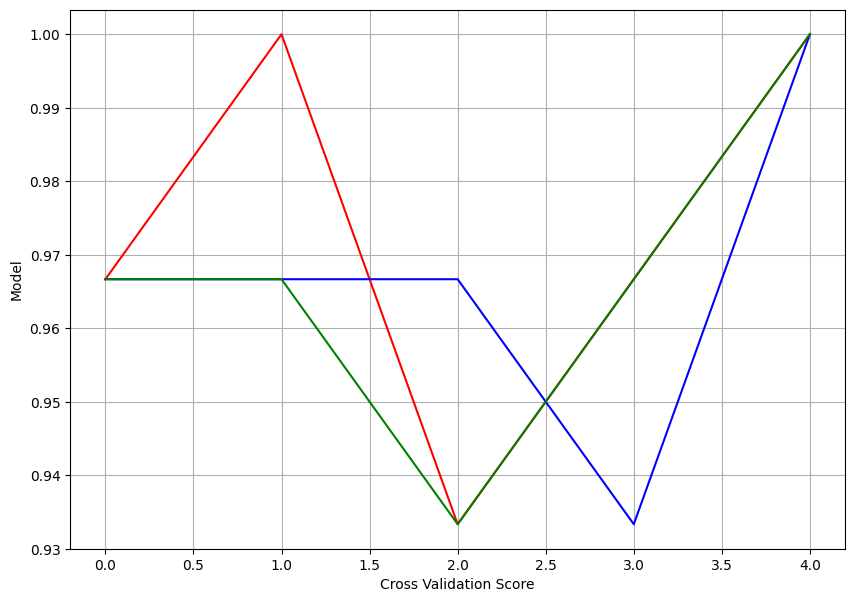

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize = (10,7))
plt.plot(x,color = 'red',label ='x')
plt.plot(y,color = 'blue',label ='y')
plt.plot(z,color = 'green',label ='z')
plt.xlabel('Cross Validation Score')
plt.ylabel('Model')
plt.grid(True)
plt.show()